<a href="https://colab.research.google.com/github/nmdra/ML-Assignment/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### KNN Classification - Student Dropout & Academic Success

Dataset: UCI ML Repository (ID: 697)

In [3]:
# Imports

!pip install ucimlrepo imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.feature_selection import VarianceThreshold

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)

# Class imbalance fix
from imblearn.over_sampling import SMOTE

In [5]:
dataset = fetch_ucirepo(id=697) # Dataset
X = dataset.data.features
y = dataset.data.targets

print('=' * 45)
print('         DATASET OVERVIEW')
print('=' * 45)
print(f'  Rows (students):    {X.shape[0]}')
print(f'  Columns (features): {X.shape[1]}')
print('=' * 45)
print('\nTarget distribution:')
counts = y['Target'].value_counts()
for label, count in counts.items():
    pct = count / len(y) * 100
    bar = chr(9608) * int(pct / 2)
    print(f'  {label:<12} {count:>5}  ({pct:.1f}%)  {bar}')
print('\nMissing values:', X.isnull().sum().sum())
print('\nFirst 5 rows:')
X.head()


         DATASET OVERVIEW
  Rows (students):    4424
  Columns (features): 36

Target distribution:
  Graduate      2209  (49.9%)  ████████████████████████
  Dropout       1421  (32.1%)  ████████████████
  Enrolled       794  (17.9%)  ████████

Missing values: 0

First 5 rows:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [6]:
# Impute
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
print(f'Step 1 | Shape after imputation: {X_imputed.shape}')

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y['Target'])
print(f'Step 2 | Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Remove low-variance features
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X_imputed)
removed = X_imputed.shape[1] - X_selected.shape[1]
print(f'Step 3 | Features: {X_imputed.shape[1]} -> {X_selected.shape[1]}  ({removed} removed)')

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
print(f'Step 4 | Scaled shape: {X_scaled.shape}')

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f'\nStep 5 | Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'         Train distribution: {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'         Test  distribution: {dict(zip(le.classes_, np.bincount(y_test)))}')


Step 1 | Shape after imputation: (4424, 36)
Step 2 | Encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Step 3 | Features: 36 -> 36  (0 removed)
Step 4 | Scaled shape: (4424, 36)

Step 5 | Train: 3539  |  Test: 885
         Train distribution: {'Dropout': np.int64(1137), 'Enrolled': np.int64(635), 'Graduate': np.int64(1767)}
         Test  distribution: {'Dropout': np.int64(284), 'Enrolled': np.int64(159), 'Graduate': np.int64(442)}


  K   Train acc   CV acc (5-fold)    Test acc
------------------------------------------------
  1      1.0000          0.6519 +/- 0.0097      0.6294
  2      0.8514          0.6163 +/- 0.0139      0.6045
  3      0.8242          0.6770 +/- 0.0088      0.6644
  4      0.8079          0.6742 +/- 0.0101      0.6633
  5      0.7985          0.6954 +/- 0.0188      0.6667
  6      0.7830          0.6988 +/- 0.0113      0.6723
  7      0.7742          0.7005 +/- 0.0113      0.6757
  8      0.7660          0.7070 +/- 0.0065      0.6927
  9      0.7615          0.7016 +/- 0.0096      0.6915
 10      0.7556          0.7056 +/- 0.0108      0.6881
 11      0.7528          0.7101 +/- 0.0064      0.6949
 12      0.7494          0.7152 +/- 0.0135      0.6983
 13      0.7491          0.7138 +/- 0.0116      0.6949
 14      0.7516          0.7140 +/- 0.0117      0.7017
 15      0.7468          0.7152 +/- 0.0095      0.7006
 16      0.7420          0.7121 +/- 0.0106      0.7051
 17      0.7417          

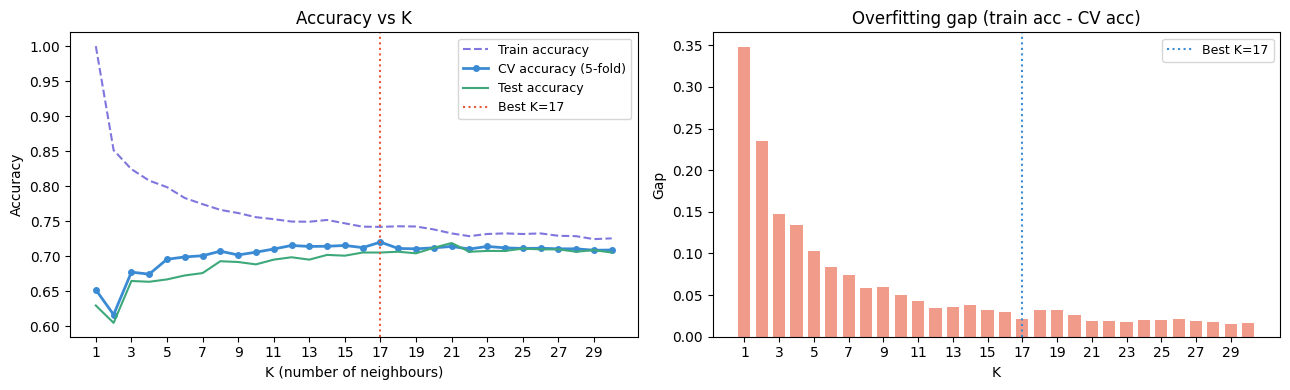

In [7]:
k_range = range(1, 31)
train_acc, test_acc, cv_scores_list = [], [], []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'K':>3}  {'Train acc':>10}  {'CV acc (5-fold)':>16}  {'Test acc':>10}")
print('-' * 48)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, knn.predict(X_train))
    cv_acc = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    te_acc = accuracy_score(y_test, knn.predict(X_test))
    train_acc.append(tr_acc)
    cv_scores_list.append(cv_acc.mean())
    test_acc.append(te_acc)
    print(f'{k:>3}  {tr_acc:>10.4f}  {cv_acc.mean():>14.4f} +/- {cv_acc.std():.4f}  {te_acc:>10.4f}')

# FIX: best_k is set dynamically - never hardcode this value
best_k = list(k_range)[np.argmax(cv_scores_list)]
print(f'\nBest K by cross-validation: K={best_k}  (CV acc={max(cv_scores_list):.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_range, train_acc, label='Train accuracy', color='#7F77DD', linewidth=1.5, linestyle='--')
axes[0].plot(k_range, cv_scores_list, label='CV accuracy (5-fold)', color='#3B8BD4', linewidth=2, marker='o', markersize=4)
axes[0].plot(k_range, test_acc, label='Test accuracy', color='#3DA87A', linewidth=1.5)
axes[0].axvline(best_k, linestyle=':', color='#E8593C', linewidth=1.5, label=f'Best K={best_k}')
axes[0].set_title('Accuracy vs K')
axes[0].set_xlabel('K (number of neighbours)')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(1, 31, 2))

gap = np.array(train_acc) - np.array(cv_scores_list)
axes[1].bar(k_range, gap, color='#E8593C', alpha=0.6, width=0.7)
axes[1].axvline(best_k, linestyle=':', color='#3B8BD4', linewidth=1.5, label=f'Best K={best_k}')
axes[1].set_title('Overfitting gap (train acc - CV acc)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Gap')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()


In [8]:
# FIX: OPTIMAL_K set dynamically from best_k - never hardcoded
OPTIMAL_K = best_k

knn_uniform = KNeighborsClassifier(
    n_neighbors=OPTIMAL_K,
    metric='euclidean',
    weights='uniform',     # baseline: all neighbours vote equally
    algorithm='auto',      # sklearn picks kd_tree/ball_tree/brute
    n_jobs=-1
)
knn_uniform.fit(X_train, y_train)
y_pred = knn_uniform.predict(X_test)

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wt  = f1_score(y_test, y_pred, average='weighted')

print(f'Baseline KNN trained  (K={OPTIMAL_K}, uniform weights)')
print(f'  Accuracy:      {acc:.4f}')
print(f'  F1 (macro):    {f1_mac:.4f}')
print(f'  F1 (weighted): {f1_wt:.4f}')


Baseline KNN trained  (K=17, uniform weights)
  Accuracy:      0.7051
  F1 (macro):    0.5951
  F1 (weighted): 0.6765


     BASELINE KNN EVALUATION (uniform)
  Accuracy:      0.7051
  F1 (macro):    0.5951
  F1 (weighted): 0.6765

Classification report:
              precision    recall  f1-score   support

     Dropout       0.80      0.62      0.70       284
    Enrolled       0.44      0.21      0.28       159
    Graduate       0.70      0.94      0.80       442

    accuracy                           0.71       885
   macro avg       0.65      0.59      0.60       885
weighted avg       0.69      0.71      0.68       885



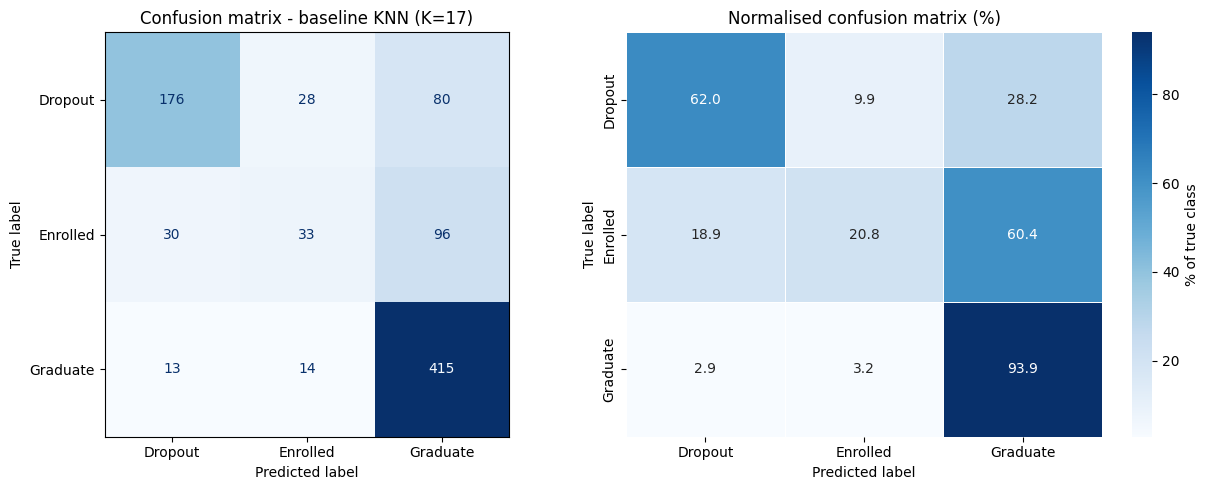


Per-class recall (% correctly identified):
  Dropout        62.0%  ████████████
  Enrolled       20.8%  ████
  Graduate       93.9%  ██████████████████


In [9]:
print('=' * 50)
print('     BASELINE KNN EVALUATION (uniform)')
print('=' * 50)
print(f'  Accuracy:      {accuracy_score(y_test, y_pred):.4f}')
print(f'  F1 (macro):    {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'  F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.4f}')
print('=' * 50)
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion matrix - baseline KNN (K={OPTIMAL_K})')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of true class'}, ax=axes[1])
axes[1].set_title('Normalised confusion matrix (%)')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
plt.tight_layout()
plt.show()

print('\nPer-class recall (% correctly identified):')
for i, cls in enumerate(le.classes_):
    recall = cm[i, i] / cm[i].sum() * 100
    bar = chr(9608) * int(recall / 5)
    print(f'  {cls:<12} {recall:>6.1f}%  {bar}')


Best K for weighted KNN: K=17  (CV acc=0.7152)

Uniform  KNN (K=17)   -> Accuracy: 0.7051  | F1 macro: 0.5951
Weighted KNN (K=17)   -> Accuracy: 0.7085  | F1 macro: 0.5942
Improvement from distance weighting: +0.0034 (+0.34%)


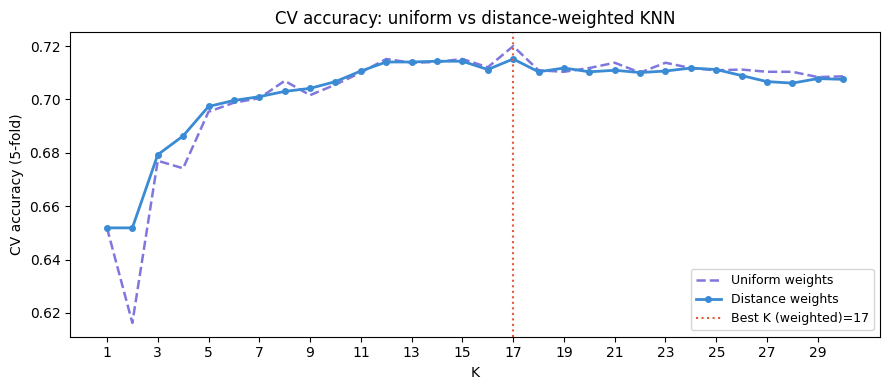

In [11]:
# Find best K for distance-weighted KNN separately
cv_weighted_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in range(1, 31):
    knn_w = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean', n_jobs=-1)
    cv_w = cross_val_score(knn_w, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_weighted_scores.append(cv_w.mean())

best_k_weighted = list(range(1, 31))[np.argmax(cv_weighted_scores)]
print(f'Best K for weighted KNN: K={best_k_weighted}  (CV acc={max(cv_weighted_scores):.4f})')

OPTIMAL_K_W = best_k_weighted

knn_weighted = KNeighborsClassifier(
    n_neighbors=OPTIMAL_K_W,
    metric='euclidean',
    weights='distance',    # closer neighbours get more vote weight
    algorithm='auto',
    n_jobs=-1
)
knn_weighted.fit(X_train, y_train)
y_pred_bw = knn_weighted.predict(X_test)  # bw = best weighted (no SMOTE)

acc_bw  = accuracy_score(y_test, y_pred_bw)
f1_bw_m = f1_score(y_test, y_pred_bw, average='macro')
f1_bw_w = f1_score(y_test, y_pred_bw, average='weighted')

print(f'\nUniform  KNN (K={OPTIMAL_K})   -> Accuracy: {accuracy_score(y_test, y_pred):.4f}  | F1 macro: {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Weighted KNN (K={OPTIMAL_K_W})   -> Accuracy: {acc_bw:.4f}  | F1 macro: {f1_bw_m:.4f}')
delta = acc_bw - accuracy_score(y_test, y_pred)
print(f'Improvement from distance weighting: {delta:+.4f} ({delta*100:+.2f}%)')

# Compare K curves for both weighting strategies
cv_uniform_scores = []
for k in range(1, 31):
    cv_u = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, weights='uniform', n_jobs=-1),
        X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1
    )
    cv_uniform_scores.append(cv_u.mean())

plt.figure(figsize=(9, 4))
plt.plot(range(1, 31), cv_uniform_scores, label='Uniform weights', color='#7F77DD', linewidth=1.8, linestyle='--')
plt.plot(range(1, 31), cv_weighted_scores, label='Distance weights', color='#3B8BD4', linewidth=2, marker='o', markersize=4)
plt.axvline(best_k_weighted, linestyle=':', color='#E8593C', linewidth=1.5, label=f'Best K (weighted)={best_k_weighted}')
plt.title('CV accuracy: uniform vs distance-weighted KNN')
plt.xlabel('K')
plt.ylabel('CV accuracy (5-fold)')
plt.legend(fontsize=9)
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()


Class distribution BEFORE SMOTE:
  Dropout       1137  ██████████████████████
  Enrolled       635  ████████████
  Graduate      1767  ███████████████████████████████████

Class distribution AFTER SMOTE:
  Dropout       1767  ███████████████████████████████████
  Enrolled      1767  ███████████████████████████████████
  Graduate      1767  ███████████████████████████████████

Weighted KNN (no SMOTE)  -> Accuracy: 0.7085  | F1 macro: 0.5942
Weighted KNN (+ SMOTE)   -> Accuracy: 0.5977  | F1 macro: 0.5778
Change from SMOTE: -0.1107 (-11.07%)

Note: SMOTE may slightly reduce overall accuracy but improves
recall for the minority Enrolled class - check per-class report.


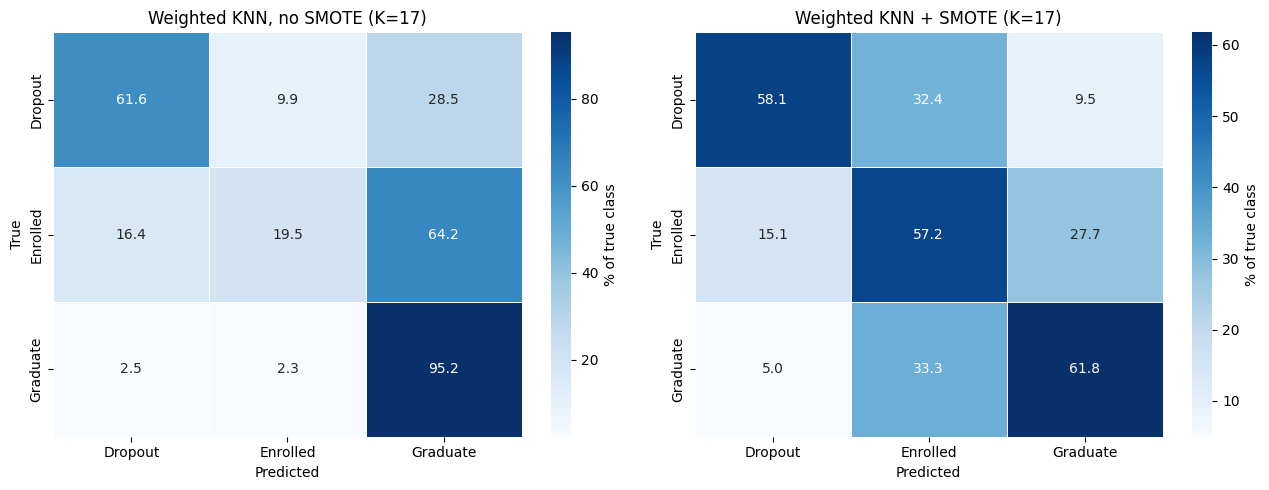


Per-class recall comparison:
Class           No SMOTE     + SMOTE    Change
----------------------------------------------
Dropout            61.6%       58.1%     -3.5%
Enrolled           19.5%       57.2%    +37.7%
Graduate           95.2%       61.8%    -33.5%


In [12]:
print('Class distribution BEFORE SMOTE:')
for cls, cnt in zip(le.classes_, np.bincount(y_train)):
    bar = chr(9608) * int(cnt / 50)
    print(f'  {cls:<12} {cnt:>5}  {bar}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nClass distribution AFTER SMOTE:')
for cls, cnt in zip(le.classes_, np.bincount(y_train_sm)):
    bar = chr(9608) * int(cnt / 50)
    print(f'  {cls:<12} {cnt:>5}  {bar}')

# FIX: Added missing comma after n_neighbors=OPTIMAL_K_W
knn_smote = KNeighborsClassifier(
    n_neighbors=OPTIMAL_K_W,   # comma was missing here in original
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
knn_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = knn_smote.predict(X_test)

acc_sm  = accuracy_score(y_test, y_pred_sm)
f1_sm_m = f1_score(y_test, y_pred_sm, average='macro')
f1_sm_w = f1_score(y_test, y_pred_sm, average='weighted')

print(f'\nWeighted KNN (no SMOTE)  -> Accuracy: {acc_bw:.4f}  | F1 macro: {f1_bw_m:.4f}')
print(f'Weighted KNN (+ SMOTE)   -> Accuracy: {acc_sm:.4f}  | F1 macro: {f1_sm_m:.4f}')
delta_sm = acc_sm - acc_bw
print(f'Change from SMOTE: {delta_sm:+.4f} ({delta_sm*100:+.2f}%)')
print('\nNote: SMOTE may slightly reduce overall accuracy but improves')
print('recall for the minority Enrolled class - check per-class report.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(
    axes,
    [y_pred_bw, y_pred_sm],
    [f'Weighted KNN, no SMOTE (K={OPTIMAL_K_W})',
     f'Weighted KNN + SMOTE (K={OPTIMAL_K_W})']
):
    cm_n = confusion_matrix(y_test, pred).astype(float)
    cm_n = cm_n / cm_n.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_n, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor='white', ax=ax,
                cbar_kws={'label': '% of true class'})
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

print('\nPer-class recall comparison:')
print(f"{'Class':<12}  {'No SMOTE':>10}  {'+ SMOTE':>10}  {'Change':>8}")
print('-' * 46)
cm_bw_raw = confusion_matrix(y_test, y_pred_bw)
cm_sm_raw = confusion_matrix(y_test, y_pred_sm)
for i, cls in enumerate(le.classes_):
    r_bw = cm_bw_raw[i, i] / cm_bw_raw[i].sum() * 100
    r_sm = cm_sm_raw[i, i] / cm_sm_raw[i].sum() * 100
    print(f'{cls:<12}  {r_bw:>9.1f}%  {r_sm:>9.1f}%  {r_sm-r_bw:>+7.1f}%')

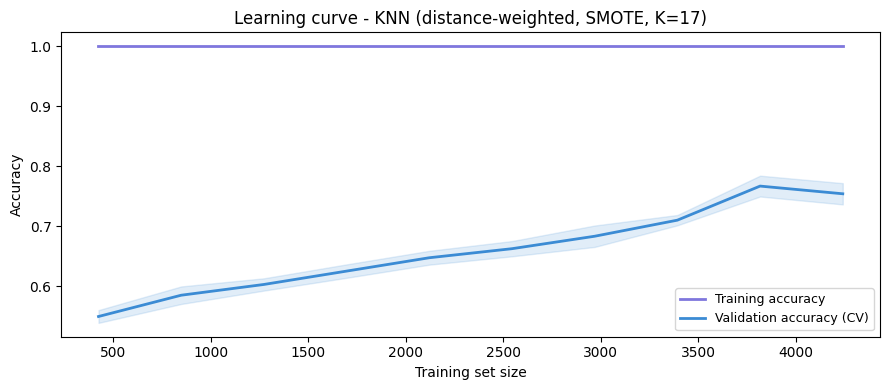

Final training accuracy:        1.0000
Final validation accuracy:      0.7540
Train-val gap (overfit signal): 0.2460
-> High variance (overfitting). Consider larger K or fewer features.
-> Curve still rising - more training data may help further.


In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(n_neighbors=OPTIMAL_K_W, weights='distance',
                          metric='euclidean', n_jobs=-1),
    X_train_sm, y_train_sm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 4))
plt.plot(train_sizes, train_mean, label='Training accuracy', color='#7F77DD', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#7F77DD')
plt.plot(train_sizes, val_mean, label='Validation accuracy (CV)', color='#3B8BD4', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3B8BD4')
plt.title(f'Learning curve - KNN (distance-weighted, SMOTE, K={OPTIMAL_K_W})')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final training accuracy:        {train_mean[-1]:.4f}')
print(f'Final validation accuracy:      {val_mean[-1]:.4f}')
print(f'Train-val gap (overfit signal): {gap:.4f}')
if gap > 0.10:
    print('-> High variance (overfitting). Consider larger K or fewer features.')
elif val_mean[-1] < 0.72:
    print('-> High bias (underfitting). Consider smaller K or more features.')
else:
    print('-> Good bias-variance balance.')
if val_mean[-1] - val_mean[0] > 0.02:
    print('-> Curve still rising - more training data may help further.')
else:
    print('-> Curve has plateaued - more data unlikely to help significantly.')


                 KNN FINAL RESULTS COMPARISON
Model                                 Accuracy   F1 macro   F1 weighted
--------------------------------------------------------------------
KNN uniform  (no SMOTE)                 0.7051     0.5951        0.6765
KNN weighted (no SMOTE)                 0.7085     0.5942        0.6773
KNN weighted (+ SMOTE)                  0.5977     0.5778        0.6277

Best model by F1 macro: KNN uniform  (no SMOTE)

Detailed classification report:
              precision    recall  f1-score   support

     Dropout       0.80      0.62      0.70       284
    Enrolled       0.44      0.21      0.28       159
    Graduate       0.70      0.94      0.80       442

    accuracy                           0.71       885
   macro avg       0.65      0.59      0.60       885
weighted avg       0.69      0.71      0.68       885



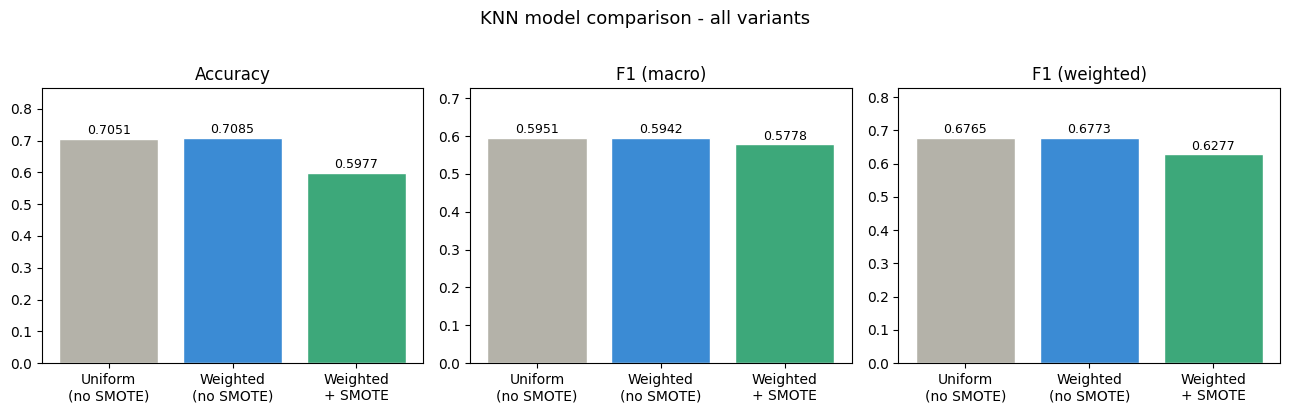

In [14]:
models_results = {
    'KNN uniform  (no SMOTE)': (y_pred,    y_test),
    'KNN weighted (no SMOTE)': (y_pred_bw, y_test),
    'KNN weighted (+ SMOTE)':  (y_pred_sm, y_test),
}

print('=' * 68)
print('                 KNN FINAL RESULTS COMPARISON')
print('=' * 68)
print(f"{'Model':<35}  {'Accuracy':>9}  {'F1 macro':>9}  {'F1 weighted':>12}")
print('-' * 68)
for name, (pred, true) in models_results.items():
    a  = accuracy_score(true, pred)
    fm = f1_score(true, pred, average='macro')
    fw = f1_score(true, pred, average='weighted')
    print(f'{name:<35}  {a:>9.4f}  {fm:>9.4f}  {fw:>12.4f}')
print('=' * 68)

# Best model by macro F1 (fairer for imbalanced classes)
best_name = max(models_results,
                key=lambda n: f1_score(models_results[n][1],
                                       models_results[n][0], average='macro'))
best_pred, best_true = models_results[best_name]
print(f'\nBest model by F1 macro: {best_name}')
print('\nDetailed classification report:')
print(classification_report(best_true, best_pred, target_names=le.classes_))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
names   = ['Uniform\n(no SMOTE)', 'Weighted\n(no SMOTE)', 'Weighted\n+ SMOTE']
palette = ['#B4B2A9', '#3B8BD4', '#3DA87A']
accs = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_bw), accuracy_score(y_test, y_pred_sm)]
f1ms = [f1_score(y_test, y_pred, average='macro'), f1_score(y_test, y_pred_bw, average='macro'), f1_score(y_test, y_pred_sm, average='macro')]
f1ws = [f1_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred_bw, average='weighted'), f1_score(y_test, y_pred_sm, average='weighted')]
for ax, vals, title in zip(axes, [accs, f1ms, f1ws], ['Accuracy', 'F1 (macro)', 'F1 (weighted)']):
    bars = ax.bar(names, vals, color=palette, edgecolor='white')
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(vals) * 1.22))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('KNN model comparison - all variants', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
